In [ ]:
def otsu_binarization(image):
    """
    使用大津法对彩色图像进行二值化，并返回二值化后的图像。

    参数：
        image：一个3D列表，表示彩色图像。每个元素image[i][j]是一个[R, G, B]的列表。

    返回：
        一个2D列表，表示二值化后的图像，其中1表示前景，0表示背景。
    """
    # 获取图像的尺寸
    height = len(image)
    width = len(image[0])

    # 第一步：将彩色图像转换为灰度图像
    grayscale = []
    for i in range(height):
        grayscale_row = []
        for j in range(width):
            # 提取RGB值
            R, G, B = image[i][j]
            # 使用亮度公式计算灰度值
            gray = int(0.2989 * R + 0.5870 * G + 0.1140 * B)
            grayscale_row.append(gray)
        grayscale.append(grayscale_row)

    # 第二步：计算灰度值的直方图
    histogram = [0] * 256  # 初始化256个零的直方图
    for i in range(height):
        for j in range(width):
            gray_value = grayscale[i][j]
            histogram[gray_value] += 1  # 增加对应灰度值的计数

    # 第三步：实现大津法寻找最佳阈值
    total_pixels = height * width
    sum_total = 0  # 所有像素灰度值的总和
    for t in range(256):
        sum_total += t * histogram[t]

    sumB = 0  # 背景灰度值的累积和
    wB = 0    # 背景的权重（像素数）
    maximum_between_class_variance = 0
    optimal_threshold = 0

    for t in range(256):
        wB += histogram[t]  # 背景类的权重
        if wB == 0:
            continue  # 如果没有像素属于该类，跳过
        wF = total_pixels - wB  # 前景类的权重
        if wF == 0:
            break  # 所有像素都属于背景，停止循环
        sumB += t * histogram[t]  # 背景灰度值的累积和
        mB = sumB / wB  # 背景类的平均灰度值
        mF = (sum_total - sumB) / wF  # 前景类的平均灰度值
        # 计算类间方差
        between_class_variance = wB * wF * (mB - mF) ** 2
        # 更新最大类间方差和最佳阈值
        if between_class_variance > maximum_between_class_variance:
            maximum_between_class_variance = between_class_variance
            optimal_threshold = t

    # 第四步：使用最佳阈值创建二值化图像
    binary_image = []
    for i in range(height):
        binary_row = []
        for j in range(width):
            if grayscale[i][j] > optimal_threshold:
                binary_row.append(1)  # 前景
            else:
                binary_row.append(0)  # 背景
        binary_image.append(binary_row)

    return binary_image

In [40]:
def RGB2GRAY(image):
    height = len(image)
    width = len(image[0])
    grayscale = []
    for i in range(height):
        grayscale_row = []
        for j in range(width):
            R,G,B = image[i][j]
            gray = int(0.299*R + 0.589*G + 0.114*B)
            grayscale_row.append(gray)
        grayscale.append(grayscale_row)
    return grayscale

In [47]:
def Gray_hist(image):
    gray_image = RGB2GRAY(image)
    histogram = [0] * 256
    height = len(gray_image)
    width = len(gray_image[0])
    for i in range(height):
        for j in range(width):
            gray_value = gray_image[i][j]
            histogram[gray_value] += 1
    return histogram

In [63]:
def otsu_binarization(image):
    height = len(image)
    width = len(image[0])
    histogram = Gray_hist(image)
    total_pixels = height*width
    sum_total = 0
    for t in range(256):
        sum_total+=t*histogram[t]

    sumB = 0
    wB = 0
    maximum_between_class_variance = 0
    optimal_threshold = 0

    for t in range(256):
        wB += histogram[t]
        if wB == 0:
            continue
        wF = total_pixels - wB
        if wF == 0:
            break
        sumB += t*histogram[t]
        mB = sumB /wB
        mF = (sum_total-sumB)/ wF

        between_class_variance = wB * wF * (mB-mF)**2
        if between_class_variance > maximum_between_class_variance:
            maximum_between_class_variance = between_class_variance
            optimal_threshold = t

    return optimal_threshold

In [81]:
def binaryImage(image):
    optimal_threshold = otsu_binarization(image)
    binary_image = []
    gray_img = RGB2GRAY(image)
    print(optimal_threshold)
    for i in range(len(image)):
        binary_image_row=[]
        for j in range(len(image[0])):
            if gray_img[i][j] > optimal_threshold:
                binary_image_row.append(255)
            else:
                binary_image_row.append(0)
        binary_image.append(binary_image_row)
    return binary_image


In [92]:
converted_img = binaryImage(img)

154


In [89]:
import cv2

def read_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Error")
    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img_list = img_rgb.tolist()
    return img_list

In [90]:
path = "./test.png"
img = read_image(path)
hist = Gray_hist(img)

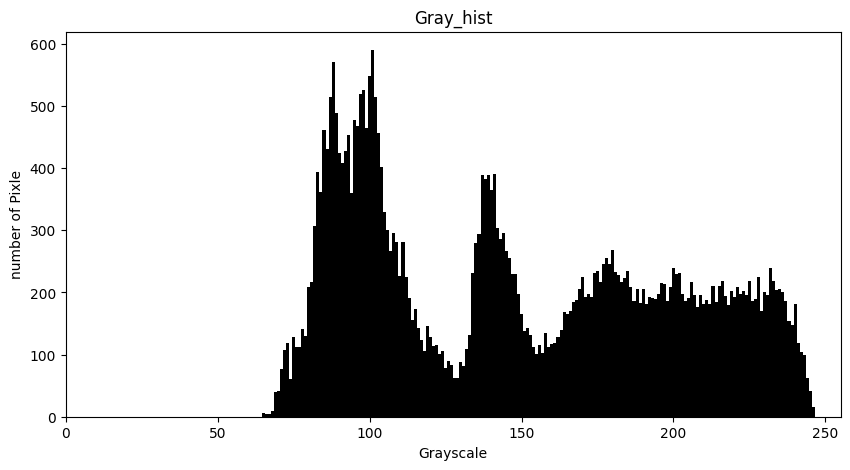

In [91]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))  
plt.title('Gray_hist')  
plt.xlabel('Grayscale')  
plt.ylabel('number of Pixle')  
plt.bar(range(256), Gray_hist(q), color='black', width=1)  
plt.xlim([0, 255])  
plt.show()  

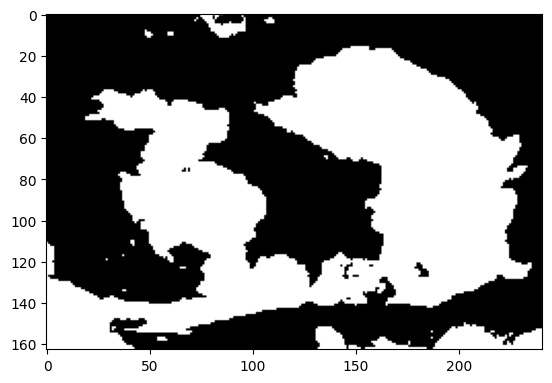

In [97]:
import numpy as np
bin_array = np.array(converted_img,dtype=np.uint8)
plt.imshow(bin_array,cmap='gray')  
plt.show()  